Setup & Imports

In [8]:
!pip install yfinance -q
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
print("✓ All libraries imported successfully!")
print(f"  NumPy version: {np.__version__}")
print(f"  Pandas version: {pd.__version__}")


✓ All libraries imported successfully!
  NumPy version: 2.0.2
  Pandas version: 2.2.2


Parameters Class

In [9]:
class Parameters:
    def __init__(self):
        self.S0 = 100
        self.K = 100
        self.T = 1.0
        self.r = 0.05
        self.sigma = 0.25
        self.mu = 0.05

        self.lambda_tc = 0.01

        self.dt = 1/100
        self.n_sims = 50000

    def __str__(self):
        return f"""
Parameters:
  S0 (Initial Price):     ${self.S0}
  K (Strike):             ${self.K}
  T (Maturity):           {self.T} year
  r (Risk-free rate):     {self.r*100}%
  σ (Volatility):         {self.sigma*100}%
  λ (Transaction cost):   {self.lambda_tc*100}%
  dt (Rehedge interval):  {self.dt} year
  Simulations:            {self.n_sims:,}
"""

params = Parameters()
print(params)



Parameters:
  S0 (Initial Price):     $100
  K (Strike):             $100
  T (Maturity):           1.0 year
  r (Risk-free rate):     5.0%
  σ (Volatility):         25.0%
  λ (Transaction cost):   1.0%
  dt (Rehedge interval):  0.01 year
  Simulations:            50,000



Black-Scholes Functions

In [10]:
def bs_call_price(S, K, T, r, sigma):
    if T <= 1e-10:
        return max(S - K, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return price


def bs_delta(S, K, T, r, sigma):
    if T <= 1e-10:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    delta = norm.cdf(d1)
    return delta


def bs_gamma(S, K, T, r, sigma):
    if T <= 1e-10:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

print("Testing Black-Scholes functions:")
S_test = 100
K_test = 100
T_test = 1.0
r_test = 0.05
sigma_test = 0.25
price = bs_call_price(S_test, K_test, T_test, r_test, sigma_test)
delta = bs_delta(S_test, K_test, T_test, r_test, sigma_test)
gamma = bs_gamma(S_test, K_test, T_test, r_test, sigma_test)
print(f"  Call Price: ${price:.4f}")
print(f"  Delta:      {delta:.4f}")
print(f"  Gamma:      {gamma:.6f}")
print("✓ Black-Scholes functions work!")


Testing Black-Scholes functions:
  Call Price: $12.3360
  Delta:      0.6274
  Gamma:      0.015137
✓ Black-Scholes functions work!


Leland's Modified Volatility

In [11]:
def leland_volatility(sigma, lambda_tc, dt, short_gamma=True):
    A = (lambda_tc / sigma) * np.sqrt(8 / (np.pi * dt))
    if short_gamma:
        sigma_m = sigma * np.sqrt(1 + A)
    else:
        sigma_m = sigma * np.sqrt(max(1 - A, 0.01))
    return sigma_m


print("Testing Leland's volatility adjustment:")
sigma_original = 0.25
lambda_tc = 0.01
dt = 1/100

sigma_short = leland_volatility(sigma_original, lambda_tc, dt, short_gamma=True)
sigma_long = leland_volatility(sigma_original, lambda_tc, dt, short_gamma=False)

print(f"  Original σ:        {sigma_original:.4f} ({sigma_original*100:.2f}%)")
print(f"  Short call σ_m:    {sigma_short:.4f} ({sigma_short*100:.2f}%)")
print(f"  Long call σ_m:     {sigma_long:.4f} ({sigma_long*100:.2f}%)")
print(f"  Adjustment factor: {(sigma_short/sigma_original - 1)*100:.2f}%")
print("✓ Leland functions work!")


Testing Leland's volatility adjustment:
  Original σ:        0.2500 (25.00%)
  Short call σ_m:    0.3200 (32.00%)
  Long call σ_m:     0.1504 (15.04%)
  Adjustment factor: 28.00%
✓ Leland functions work!


Stock Price Simulation

Testing stock simulation...


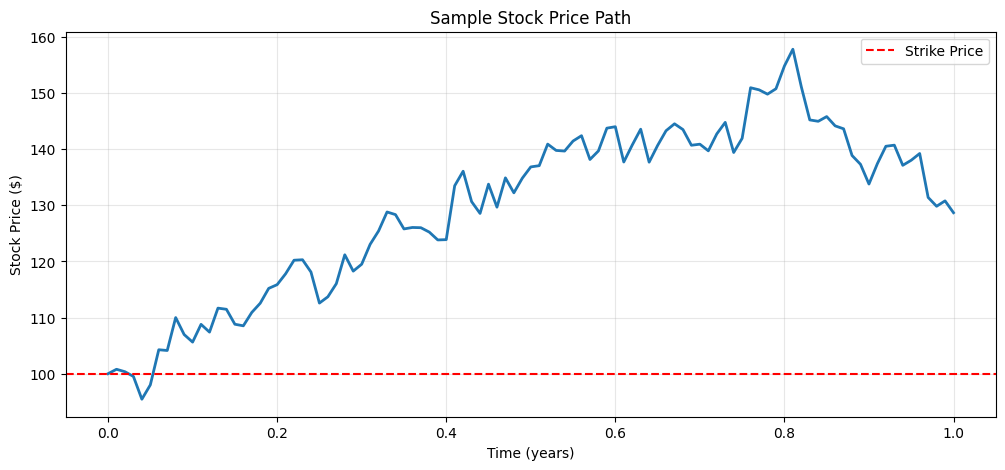

  Started at: $100.00
  Ended at:   $128.69
  Min price:  $95.45
  Max price:  $157.83
✓ Stock simulation works!


In [12]:
def simulate_stock_path(S0, mu, sigma, T, dt):
    n_steps = int(T / dt)
    S = np.zeros(n_steps + 1)
    S[0] = S0
    for i in range(n_steps):
        epsilon = np.random.normal(0, 1)
        S[i+1] = S[i] * np.exp((mu - 0.5*sigma**2)*dt +
                                sigma*np.sqrt(dt)*epsilon)
    return S
print("Testing stock simulation...")
S_path = simulate_stock_path(params.S0, params.mu, params.sigma,
                              params.T, params.dt)
plt.figure(figsize=(12, 5))
time_axis = np.linspace(0, params.T, len(S_path))
plt.plot(time_axis, S_path, linewidth=2)
plt.axhline(y=params.K, color='r', linestyle='--', label='Strike Price')
plt.xlabel('Time (years)')
plt.ylabel('Stock Price ($)')
plt.title('Sample Stock Price Path')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"  Started at: ${S_path[0]:.2f}")
print(f"  Ended at:   ${S_path[-1]:.2f}")
print(f"  Min price:  ${S_path.min():.2f}")
print(f"  Max price:  ${S_path.max():.2f}")
print("✓ Stock simulation works!")


Hedging Simulation (CORE)

In [13]:
def simulate_hedging(S_path, K, r, sigma, dt, lambda_tc, strategy='BS'):
    n_steps = len(S_path) - 1
    T_total = n_steps * dt
    if strategy == 'Leland':
        sigma_hedge = leland_volatility(sigma, lambda_tc, dt, short_gamma=True)
    else:
        sigma_hedge = sigma
    portfolio_value = 0.0
    shares_held = 0.0
    total_tc = 0.0
    portfolio_history = []
    delta_history = []

    for i in range(n_steps):
        S = S_path[i]
        T_remain = T_total - i*dt
        target_delta = bs_delta(S, K, T_remain, r, sigma_hedge)
        shares_to_trade = target_delta - shares_held
        transaction_cost = lambda_tc * abs(shares_to_trade) * S

        portfolio_value -= shares_to_trade * S

        portfolio_value -= transaction_cost

        portfolio_value *= np.exp(r * dt)

        shares_held = target_delta
        total_tc += transaction_cost

        portfolio_history.append(portfolio_value)
        delta_history.append(target_delta)

    S_final = S_path[-1]
    option_payoff = max(S_final - K, 0)

    portfolio_value += shares_held * S_final
    portfolio_value -= option_payoff
    replication_error = portfolio_value
    return replication_error, total_tc


print("Testing hedging simulation...")
S_path = simulate_stock_path(params.S0, params.mu, params.sigma,
                              params.T, params.dt)
pnl_bs, tc_bs = simulate_hedging(S_path, params.K, params.r, params.sigma,
                                  params.dt, params.lambda_tc, 'BS')
pnl_leland, tc_leland = simulate_hedging(S_path, params.K, params.r, params.sigma,
                                          params.dt, params.lambda_tc, 'Leland')
print(f"\nFor this one path:")
print(f"  Final stock price: ${S_path[-1]:.2f}")
print(f"  Option payoff:     ${max(S_path[-1] - params.K, 0):.2f}")
print(f"\n  Black-Scholes:")
print(f"    P&L:              ${pnl_bs:.2f}")
print(f"    Transaction costs: ${tc_bs:.2f}")
print(f"\n  Leland:")
print(f"    P&L:              ${pnl_leland:.2f}")
print(f"    Transaction costs: ${tc_leland:.2f}")
print("\n✓ Hedging simulation works!")


Testing hedging simulation...

For this one path:
  Final stock price: $93.66
  Option payoff:     $0.00

  Black-Scholes:
    P&L:              $-17.13
    Transaction costs: $5.16

  Leland:
    P&L:              $-15.18
    Transaction costs: $4.36

✓ Hedging simulation works!


Monte Carlo Simulation

In [14]:
def monte_carlo_comparison(params, verbose=True):
    if verbose:
        print(f"Running {params.n_sims:,} Monte Carlo simulations...")
        print("This may take 1-2 minutes...\n")
    errors_BS = []
    errors_Leland = []
    tc_BS = []
    tc_Leland = []

    for sim in range(params.n_sims):
        S_path = simulate_stock_path(params.S0, params.mu, params.sigma,
                                      params.T, params.dt)

        error_bs, tc_bs = simulate_hedging(S_path, params.K, params.r,
                                            params.sigma, params.dt,
                                            params.lambda_tc, 'BS')
        errors_BS.append(error_bs)
        tc_BS.append(tc_bs)

        error_leland, tc_leland = simulate_hedging(S_path, params.K, params.r,
                                                     params.sigma, params.dt,
                                                     params.lambda_tc, 'Leland')
        errors_Leland.append(error_leland)
        tc_Leland.append(tc_leland)

        if verbose and (sim + 1) % 10000 == 0:
            print(f"  Completed {sim+1:,}/{params.n_sims:,} simulations")

    results = {
        'BS': {
            'mean': np.mean(errors_BS),
            'std': np.std(errors_BS),
            'mean_tc': np.mean(tc_BS),
            'errors': errors_BS
        },
        'Leland': {
            'mean': np.mean(errors_Leland),
            'std': np.std(errors_Leland),
            'mean_tc': np.mean(tc_Leland),
            'errors': errors_Leland
        }
    }
    if verbose:
        print("\n✓ Monte Carlo simulation complete!")
    return results

print("="*60)
print("MONTE CARLO SIMULATION")
print("="*60)
print(params)
results = monte_carlo_comparison(params)


MONTE CARLO SIMULATION

Parameters:
  S0 (Initial Price):     $100
  K (Strike):             $100
  T (Maturity):           1.0 year
  r (Risk-free rate):     5.0%
  σ (Volatility):         25.0%
  λ (Transaction cost):   1.0%
  dt (Rehedge interval):  0.01 year
  Simulations:            50,000

Running 50,000 Monte Carlo simulations...
This may take 1-2 minutes...

  Completed 10,000/50,000 simulations


KeyboardInterrupt: 